# Imports

In [2]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict


# Define State

In [9]:
class TemperatureState(TypedDict):
    temp_celsius: float
    temp_farenheit: float
    weather_status: str

# Convert Temperature function

In [10]:
def convert_temp(state: TemperatureState) -> TemperatureState:
    celsius = state['temp_celsius']
    # Convert C to F
    farenheit  = (celsius * 9/5) + 32
    state['temp_farenheit'] = round(farenheit, 2)

    return state

In [11]:
def label_weather(state: TemperatureState) -> TemperatureState:
    t = state['temp_farenheit']
    if t <= 32:
        state['weather_status'] = "Freezing"
    elif t <= 50:
         state['weather_status']  = "Cold"
    elif t <= 68:
        state['weather_status'] = "Mild"
    elif t <= 80:
        state['weather_status'] = "Warm"
    else:
        state['weather_status'] = "Hot"
    return state

# Define Graph and Compile Graph

In [ ]:
# Define your graph
graph = StateGraph(TemperatureState)

# add the nodes to the graph
graph.add_node('convert_temperature', convert_temp)
graph.add_node('label_weather', label_weather)

# add edges to the graph
graph.add_edge(START, 'convert_temperature')
graph.add_edge('convert_temperature', 'label_weather')
graph.add_edge('label_weather', END)

#Compile the graph
workflow = graph.compile()

# Execute Graph

In [7]:
initial_state = {'temp_celsius': 28.5}
final_state = workflow.invoke(initial_state)
print(final_state)

{'temp_celsius': 28.5, 'temp_farenheit': 83.3}


# Visualize Graph

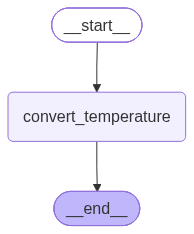

In [8]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())